In [1]:
from datasets import Dataset, disable_progress_bars
from rule import *
from g_p import Player_Base,Player_Random,alien_game

In [5]:
import pandas as pd
from rule import *

ref_rules = pd.read_csv("../data/rule_ids.csv")
ref_rules["rule_id"] = ref_rules["rule_id"].astype(str)
ref_rules["rule_num"] =ref_rules["rule_num"].astype(str)
ref_rules["full_id"] = ref_rules["rule_id"] + "_" + ref_rules["rule_num"]

In [6]:
rr = pd.read_csv("ref_real_data.csv")
rr = rr.rename(columns={"one_r_id": "rule_id", "one_r_num": "rule_num"})

In [7]:
rr["rule_id"] = rr["rule_id"].astype(str)
rr["rule_num"] =rr["rule_num"].astype(str)
rr["full_id"] = rr["rule_id"] + "_" + rr["rule_num"]

In [8]:
rr = rr.merge(ref_rules[["full_id","n1","n2","n3","n4","n5"]], on = "full_id")

In [9]:
def assign_labec(code:str,pos:int):
    "assigns the labec code to the 0.11. type stimuli format"
    if pos==0:
        labec = "l"
    elif pos==1:
        labec = "a"
    elif pos==2:
        labec = "b"
    elif pos==3:
        labec = "e"
    elif pos==4:
        labec = "c"
    
    if code == "0":
        labec = labec.lower()
    elif code == "1":
        labec = labec.upper()
    elif code == ".":
        labec= ""
    return labec

In [10]:
rr["labec"] = rr["n1"].map(assign_labec,pos=0) + rr["n2"].map(assign_labec,pos=1)+ rr["n3"].map(assign_labec,pos=2) + rr["n4"].map(assign_labec,pos=3) + rr["n5"].map(assign_labec,pos=4)

In [11]:
def translate_labec(labec:str):
    t_labec = translate_rule(labec)
    n_l_con = len(t_labec)-1
    l_pos = [0 for i in range(n_l_con)]
    #assemble rule
    verbal_rule = assemble_sentence(t_labec,l_pos)
    return verbal_rule

In [12]:
rr["verbal_rule"] = rr["labec"].map(translate_labec)

In [20]:
from tqdm import tqdm

#prepare run
rule_ds = Dataset.from_parquet("rules.parquet")
disable_progress_bars()
temp_rows = []
#run games
for v_rule_idx, v_rule in enumerate(tqdm(list(rr["verbal_rule"]))):

    #p1 = Player_Base(all_rules_ds=rule_ds)
    p1 = Player_Random(bias=0.5)
    rule = Rule(v_rule)
    rule.formalize_rule()
    g1 = alien_game(rule=rule,
                    player=p1)
    g1.play()
    #gather data
    ##n_turns
    n_t = g1.game_overview.get("meta_data").get("n_turns")
    #status
    w = g1.game_overview.get("meta_data").get("status")
    #wins
    w_t = len([i for i in g1.guesses if i ==1 ])
    #condition 
    cond= "prop_base"
    v = 1

    temp_row = {"n_correct":w_t,
                "n_turns":n_t,
                "win":w,
                "condition":cond,
                "rule":v_rule,
                "unique_id":f"{cond}_{v}",
                "game_id":f"{cond}_{v}_{v_rule_idx}"
    }
    temp_rows.append(temp_row)

df = pd.DataFrame(temp_rows)


100%|██████████| 36/36 [00:01<00:00, 22.95it/s]


In [21]:
df

,n_correct,n_turns,win,condition,rule,unique_id,game_id
0,113,199,loss,prop_base,Thin_Legs and Spots and Eyes_With_Stalk,prop_base_1,prop_base_1_0
1,117,199,loss,prop_base,Arms_Up and Blue,prop_base_1,prop_base_1_1
2,100,199,loss,prop_base,Arms_Up and Eyes_Without_Stalk,prop_base_1,prop_base_1_2
3,93,199,loss,prop_base,Arms_Up and Eyes_Without_Stalk and Blue,prop_base_1,prop_base_1_3
4,110,199,loss,prop_base,Thick_Legs and Green,prop_base_1,prop_base_1_4
5,53,96,win,prop_base,Thick_Legs and Arms_Down,prop_base_1,prop_base_1_5
6,93,199,loss,prop_base,No_Spots and Eyes_Without_Stalk and Green,prop_base_1,prop_base_1_6
7,101,199,loss,prop_base,Thin_Legs and Arms_Up,prop_base_1,prop_base_1_7
8,94,199,loss,prop_base,Thin_Legs and Spots,prop_base_1,prop_base_1_8
9,107,199,loss,prop_base,Thin_Legs and Arms_Up and Spots,prop_base_1,prop_base_1_9


In [22]:
import pandas as pd
import numpy as np
import re

import pymc as pm
import arviz as az
import nutpie
import matplotlib.pyplot as plt

import bambi as bmb 

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [59]:
model = bmb.Model("p(n_correct, n_turns) ~ 0 + win:condition",df, family="binomial")

In [60]:
model

       Formula: p(n_correct, n_turns) ~ 0 + win:condition
        Family: binomial
          Link: p = logit
  Observations: 36
        Priors: 
    target = p
        Common-level effects
            win:condition ~ Normal(mu: [0. 0.], sigma: [1. 1.])

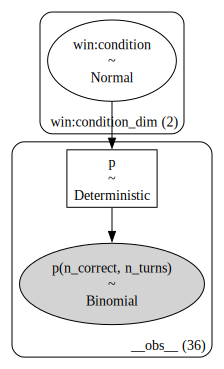

In [61]:
model.build()
model.graph()

In [62]:
# Fit the model using 1000 on each chain
nutpie_idata = model.fit(inference_method="nutpie", progressbar=True)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,1.09,1
,2000,0,1.26,1
,2000,0,1.29,3
,2000,0,1.26,3


array([[<Axes: title={'center': 'win:condition'}>,
        <Axes: title={'center': 'win:condition'}>]], dtype=object)

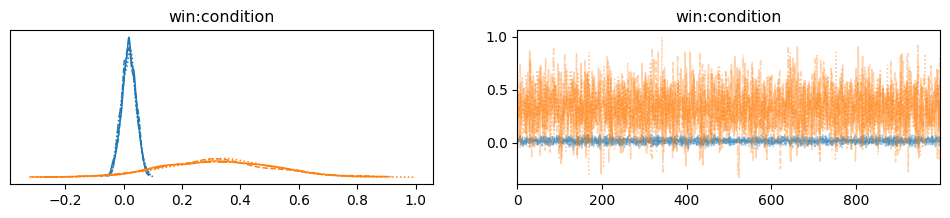

In [63]:
az.plot_trace(nutpie_idata)

In [64]:
az.summary(nutpie_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"win:condition[loss, prop_base]",0.018,0.024,-0.029,0.062,0.000,0.000,4163.0,2910.0,1.0
"win:condition[win, prop_base]",0.326,0.189,-0.029,0.673,0.003,0.003,3786.0,3037.0,1.0


In [65]:
model.predict(nutpie_idata,kind="response")

<Axes: xlabel='p(n_correct, n_turns)'>

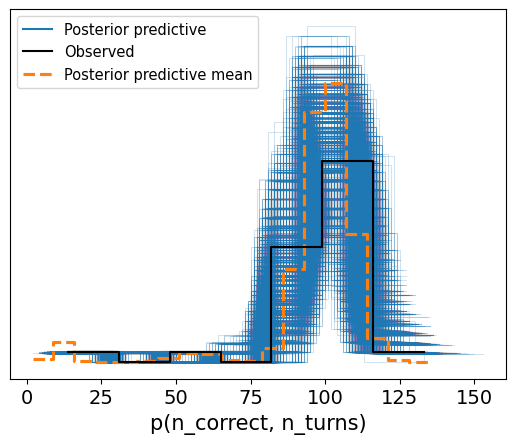

In [67]:
az.plot_ppc(nutpie_idata)

In [68]:
preds = model.predict(nutpie_idata, kind="response_params", inplace=False)
posterior_preds = np.array(preds["posterior_predictive"]["p(n_correct, n_turns)"])
new_arr = posterior_preds.reshape(-1, posterior_preds.shape[-1])
new_arr = np.transpose(new_arr)
subs_list = []
for game_id_idx, game_id in enumerate(list(df["game_id"])):
    temp_dict = {"game_id":game_id,
     "preds":new_arr[game_id_idx]}
    subs_list.append(temp_dict)

pred_df = df.merge(pd.DataFrame(subs_list), on="game_id")

In [71]:
pred_df

,n_correct,n_turns,win,condition,rule,unique_id,game_id,preds
0,113,199,loss,prop_base,Thin_Legs and Spots and Eyes_With_Stalk,prop_base_1,prop_base_1_0,"[108, 103, 96, 96, 92, 91, 96, 108, 96, 92, 11..."
1,117,199,loss,prop_base,Arms_Up and Blue,prop_base_1,prop_base_1_1,"[90, 100, 106, 95, 91, 99, 105, 108, 99, 112, ..."
2,100,199,loss,prop_base,Arms_Up and Eyes_Without_Stalk,prop_base_1,prop_base_1_2,"[118, 99, 104, 106, 96, 111, 108, 110, 104, 95..."
3,93,199,loss,prop_base,Arms_Up and Eyes_Without_Stalk and Blue,prop_base_1,prop_base_1_3,"[110, 99, 96, 97, 99, 110, 102, 112, 97, 94, 9..."
4,110,199,loss,prop_base,Thick_Legs and Green,prop_base_1,prop_base_1_4,"[100, 94, 100, 100, 101, 98, 110, 104, 108, 11..."
5,53,96,win,prop_base,Thick_Legs and Arms_Down,prop_base_1,prop_base_1_5,"[56, 58, 60, 48, 52, 58, 59, 55, 56, 56, 50, 5..."
6,93,199,loss,prop_base,No_Spots and Eyes_Without_Stalk and Green,prop_base_1,prop_base_1_6,"[107, 99, 102, 98, 104, 108, 102, 98, 98, 117,..."
7,101,199,loss,prop_base,Thin_Legs and Arms_Up,prop_base_1,prop_base_1_7,"[96, 96, 101, 94, 106, 100, 96, 104, 98, 112, ..."
8,94,199,loss,prop_base,Thin_Legs and Spots,prop_base_1,prop_base_1_8,"[113, 98, 93, 102, 86, 104, 105, 100, 103, 90,..."
9,107,199,loss,prop_base,Thin_Legs and Arms_Up and Spots,prop_base_1,prop_base_1_9,"[98, 87, 110, 99, 99, 104, 86, 99, 91, 105, 10..."


In [72]:
from scipy.stats import wasserstein_distance

In [88]:
wasserstein_distance(pred_df["preds"][1],pred_df["preds"][15])

np.float64(89.33299999999998)